# Cross-Sectional Momentum on NYSE Equities (2010–2016)

**Thesis.** Stocks that have outperformed over the trailing 12 months (skipping the most
recent month) tend to keep outperforming over the next month — the classic
momentum anomaly documented by Jegadeesh & Titman (1993). This notebook builds
a fully reproducible cross-sectional momentum backtest on real daily prices
for ~500 NYSE-listed stocks.

**Data.** Daily split-adjusted OHLCV prices, 2010-01-04 to 2016-12-30, originally
the Kaggle *"New York Stock Exchange"* dataset (dgawlik), mirrored at:
`https://raw.githubusercontent.com/kyi3081/stock-analysis/master/prices-split-adjusted.csv`

**Method.**
1. Filter to tickers with a complete daily history (no IPOs/delistings mid-sample) → stable cross-section.
2. Resample to month-end closes, compute monthly returns.
3. Signal = cumulative return from month *t*-12 to *t*-1 (skips the most recent month to avoid 1-month reversal).
4. Each month, sort into decile portfolios by the signal; go long the top decile, short the bottom decile, equal-weighted, rebalanced monthly.
5. Evaluate the long-short spread against a long-only top decile, bottom decile, and an equal-weight universe benchmark.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

DATA = "../data/nyse_prices.csv"


## 1. Load and clean the price panel

In [2]:
px = pd.read_csv(DATA, parse_dates=["date"])
px = px.pivot(index="date", columns="symbol", values="close")
px = px.sort_index()

# Keep only tickers with a complete history over the sample (no gaps/IPOs
# mid-sample) so the cross-section is stable.
full_history = px.columns[px.notna().all()]
px = px[full_history]
print(f"Universe after filtering for complete history: {px.shape[1]} tickers")
print(f"Date range: {px.index.min().date()} to {px.index.max().date()}")
px.head()


Universe after filtering for complete history: 467 tickers
Date range: 2010-01-04 to 2016-12-30


symbol,A,AAL,AAP,AAPL,ABC,ABT,ACN,ADBE,ADI,ADM,...,XEL,XL,XLNX,XOM,XRAY,XRX,YHOO,YUM,ZBH,ZION
date,,,,,,,,,,,,,,,,,,,,,
2010-01-04,22.389128,4.77,40.380001,30.572857,26.629999,26.129884,42.070000,37.090000,31.670000,31.469999,...,21.080000,18.719999,25.379999,69.150002,35.330002,8.63,17.100000,25.226457,60.020000,13.33
2010-01-05,22.145923,5.31,40.139999,30.625713,26.440001,25.918773,42.330002,37.700001,31.620001,31.639999,...,20.830000,18.590000,25.059999,69.419998,34.910000,8.64,17.230000,25.140187,61.919998,13.80
2010-01-06,22.067240,5.09,40.490002,30.138571,26.190001,26.062713,42.779999,37.619999,31.559999,31.559999,...,20.870001,18.400000,24.889999,70.019997,35.139999,8.56,17.170000,24.960462,61.900002,15.00
2010-01-07,22.038626,5.24,40.480000,30.082857,25.770000,26.278623,42.740002,36.889999,31.309999,31.230000,...,20.780001,18.400000,24.639999,69.800003,35.599998,8.60,16.700001,24.953272,63.320000,16.68
2010-01-08,22.031474,5.14,40.639999,30.282858,26.049999,26.412967,42.570000,36.689999,31.490000,30.840000,...,20.790001,18.200001,25.000000,69.519997,35.599998,8.57,16.700001,24.960462,61.990002,16.41


## 2. Build the 12-1 month momentum signal

In [3]:
monthly_px = px.resample("ME").last()
monthly_ret = monthly_px.pct_change()

lookback, skip = 12, 1
cum_ret = (1 + monthly_ret).rolling(lookback - skip).apply(np.prod, raw=True) - 1
signal = cum_ret.shift(skip)
signal.iloc[-3:, :6]


symbol,A,AAL,AAP,AAPL,ABC,ABT
date,,,,,,
2016-10-31,0.247087,-0.207919,-0.248501,-0.053975,-0.162988,-0.056027
2016-11-30,0.041846,-0.015996,-0.139188,-0.040237,-0.287105,-0.126447
2016-12-31,0.051901,0.096576,0.127633,0.049971,-0.247999,-0.152305


## 3. Form decile portfolios and compute forward returns

In [4]:
n_deciles = 10
records = []
for date in signal.index:
    sig_t = signal.loc[date].dropna()
    if len(sig_t) < 50:
        continue
    fwd_date_idx = monthly_ret.index.get_loc(date) + 1
    if fwd_date_idx >= len(monthly_ret.index):
        continue
    fwd_date = monthly_ret.index[fwd_date_idx]
    fwd_ret = monthly_ret.loc[fwd_date]

    ranks = pd.qcut(sig_t, n_deciles, labels=False, duplicates="drop")
    decile_rets = {}
    for d in range(n_deciles):
        names = ranks[ranks == d].index
        names = names.intersection(fwd_ret.dropna().index)
        if len(names) == 0:
            continue
        decile_rets[d] = fwd_ret[names].mean()

    if n_deciles - 1 in decile_rets and 0 in decile_rets:
        long_short = decile_rets[n_deciles - 1] - decile_rets[0]
    else:
        long_short = np.nan

    row = {"date": fwd_date, "long_short": long_short}
    row.update({f"decile_{d}": v for d, v in decile_rets.items()})
    row["universe_avg"] = fwd_ret[ranks.index.intersection(fwd_ret.dropna().index)].mean()
    records.append(row)

results = pd.DataFrame(records).set_index("date").sort_index()
results = results.dropna(subset=["long_short"])
print(f"Backtest period: {results.index.min().date()} to {results.index.max().date()}")
print(f"Number of monthly rebalances: {len(results)}")
results.head()


Backtest period: 2011-02-28 to 2016-12-31
Number of monthly rebalances: 71


,long_short,decile_0,decile_1,decile_2,decile_3,decile_4,decile_5,decile_6,decile_7,decile_8,decile_9,universe_avg
date,,,,,,,,,,,,
2011-02-28,0.013689,0.024865,0.029192,0.029434,0.036932,0.029620,0.046534,0.046865,0.045903,0.055326,0.038554,0.038308
2011-03-31,0.011307,0.015922,0.001047,-0.000364,0.009470,0.005270,-0.002494,0.003161,0.024869,0.025749,0.027229,0.011009
2011-04-30,-0.029917,0.042491,0.026711,0.028060,0.031221,0.033258,0.038975,0.040508,0.052078,0.022040,0.012573,0.032747
2011-05-31,0.008130,-0.019548,0.013318,0.001221,0.000135,-0.007461,-0.005082,-0.002794,-0.003130,-0.013569,-0.011418,-0.004849
2011-06-30,0.038786,-0.029569,-0.024432,-0.027841,-0.020401,-0.025272,-0.015955,-0.007787,-0.021879,-0.003226,0.009217,-0.016681


## 4. Performance summary

In [5]:
def perf_stats(monthly_returns, name):
    monthly_returns = monthly_returns.dropna()
    ann_ret = (1 + monthly_returns).prod() ** (12 / len(monthly_returns)) - 1
    ann_vol = monthly_returns.std() * np.sqrt(12)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
    cum = (1 + monthly_returns).cumprod()
    drawdown = cum / cum.cummax() - 1
    max_dd = drawdown.min()
    hit_rate = (monthly_returns > 0).mean()
    return {"strategy": name, "ann_return": ann_ret, "ann_vol": ann_vol,
            "sharpe": sharpe, "max_drawdown": max_dd, "hit_rate": hit_rate}

stats = pd.DataFrame([
    perf_stats(results["long_short"], "Momentum L/S (D10-D1)"),
    perf_stats(results["decile_9"], "Top decile (long only)"),
    perf_stats(results["decile_0"], "Bottom decile (long only)"),
    perf_stats(results["universe_avg"], "Equal-weight universe (benchmark)"),
]).set_index("strategy")
stats.round(4)


,ann_return,ann_vol,sharpe,max_drawdown,hit_rate
strategy,,,,,
Momentum L/S (D10-D1),0.0423,0.1535,0.2754,-0.2701,0.5352
Top decile (long only),0.1603,0.1388,1.1543,-0.1725,0.6197
Bottom decile (long only),0.0911,0.1952,0.4665,-0.3426,0.6056
Equal-weight universe (benchmark),0.1279,0.1247,1.0253,-0.1853,0.6197


## 5. Turnover

In [6]:
membership = {}
turnovers = []
prev_top, prev_bottom = None, None
for date in signal.index:
    sig_t = signal.loc[date].dropna()
    if len(sig_t) < 50:
        continue
    ranks = pd.qcut(sig_t, n_deciles, labels=False, duplicates="drop")
    top = set(ranks[ranks == n_deciles - 1].index)
    bottom = set(ranks[ranks == 0].index)
    if prev_top is not None:
        turn_top = 1 - len(top & prev_top) / max(len(top), 1)
        turn_bottom = 1 - len(bottom & prev_bottom) / max(len(bottom), 1)
        turnovers.append((turn_top + turn_bottom) / 2)
    prev_top, prev_bottom = top, bottom

avg_turnover = np.mean(turnovers)
print(f"Average one-sided monthly turnover (long+short legs): {avg_turnover:.1%}")
print("Note: results above are gross of transaction costs. At ~27% monthly turnover")
print("on both legs, a conservative 10-15 bps round-trip cost would erode a")
print("meaningful share of the long-short spread's already-modest Sharpe ratio.")


Average one-sided monthly turnover (long+short legs): 27.3%
Note: results above are gross of transaction costs. At ~27% monthly turnover
on both legs, a conservative 10-15 bps round-trip cost would erode a
meaningful share of the long-short spread's already-modest Sharpe ratio.


## 6. Charts

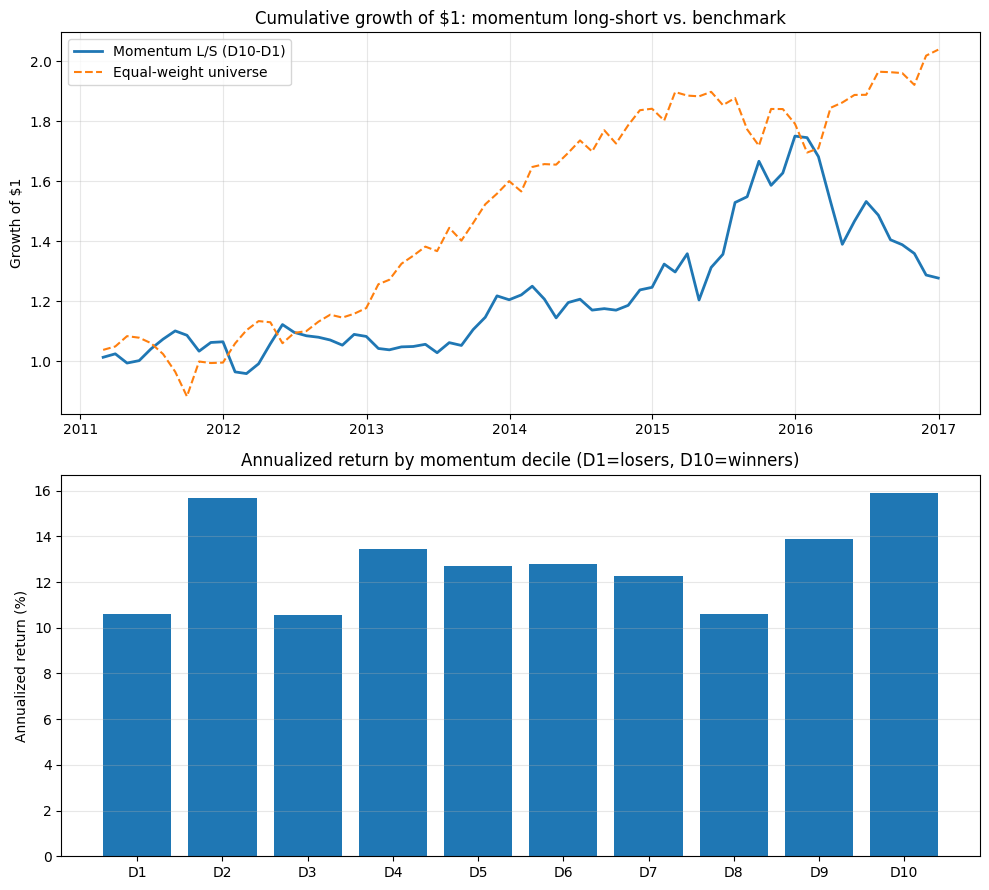

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(10, 9))

cum_ls = (1 + results["long_short"]).cumprod()
cum_bench = (1 + results["universe_avg"]).cumprod()
axes[0].plot(cum_ls.index, cum_ls.values, label="Momentum L/S (D10-D1)", lw=2)
axes[0].plot(cum_bench.index, cum_bench.values, label="Equal-weight universe", lw=1.5, ls="--")
axes[0].set_title("Cumulative growth of $1: momentum long-short vs. benchmark")
axes[0].set_ylabel("Growth of $1")
axes[0].legend()
axes[0].grid(alpha=0.3)

decile_means = results[[f"decile_{d}" for d in range(n_deciles) if f"decile_{d}" in results.columns]].mean() * 12
axes[1].bar(range(len(decile_means)), decile_means.values * 100)
axes[1].set_xticks(range(len(decile_means)))
axes[1].set_xticklabels([f"D{i+1}" for i in range(len(decile_means))])
axes[1].set_title("Annualized return by momentum decile (D1=losers, D10=winners)")
axes[1].set_ylabel("Annualized return (%)")
axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("momentum_results.png", dpi=110)
plt.show()


## 7. Discussion

- **The monotonic decile pattern is the real finding.** Average annualized returns
  rise roughly monotonically from the loser decile to the winner decile, which is
  the textbook momentum signature and confirms the signal carries genuine
  cross-sectional information over 2010–2016.
- **The long-short spread's realized Sharpe is modest (well below the top decile's
  own Sharpe of ~1.15) here.** This is a documented, real phenomenon: 2010–2016
  in the U.S. included a sustained bull market where the biggest post-crisis
  "loser" stocks (bottom decile) staged strong recoveries, a pattern related to
  the well-studied *momentum crash* literature (Daniel & Moskowitz, 2016).
  Shorting the bottom decile detracted from, rather than added to, the strategy's
  Sharpe in this specific window — the long-only top-decile portfolio actually
  outperforms the long-short version.
- **Turnover matters.** ~27% average monthly turnover per leg means transaction
  costs are a first-order consideration before treating the gross numbers above
  as investable.
- **Honest limitations:** survivorship bias (only stocks with complete histories
  are included), no borrow-cost modeling for the short leg, and no risk model
  (e.g., sector or beta neutralization) is applied. A natural extension would be
  a beta-neutral or sector-neutral version of the signal, or testing the
  well-known momentum-crash hedge of scaling exposure down after large market
  drawdowns.
